## Подготовка окружения

На первом этапе подключим библиотеки для работы с таблицами, вычислений и построения графиков. Также зададим несколько общих параметров отображения.

# Лабораторная работа №1. EDA: анализ данных о рыбах

**Дисциплина:** Введение в искусственный интеллект

## Цель исследования

Провести первичный исследовательский анализ набора данных о рыбах: изучить структуру таблицы, проверить качество данных, посмотреть распределения признаков и найти зависимости, которые могут быть полезны при дальнейшем построении модели.

Паспорт данных

| Поле | Смысл | Тип данных | Единицы / формат | Назначение | Пропуски | Диапазон / проверки | Источник |
|------|-------|------------|------------------|------------|----------|---------------------|----------|
| Species | Вид рыбы | категориальный | словарь категорий | группирующий признак | недопустимы | 7 категорий; нет пустых строк; проверить редкие виды и скрытые дубликаты написаний | ручной ввод |
| Weight | Масса рыбы | числовой (float) | граммы | целевая переменная | недопустимы | > 0; проверить хвост распределения и лог-шкалу | взвешивание |
| Length1 | Длина, вариант 1 | числовой (float) | см (предположение) | признак | недопустимы | > 0; согласована с Length2, Length3 | измерение линейкой |
| Length2 | Длина, вариант 2 | числовой (float) | см (предположение) | признак | недопустимы | > 0; согласована с Length1, Length3 | измерение линейкой |
| Length3 | Длина, вариант 3 | числовой (float) | см (предположение) | признак | недопустимы | > 0; обычно Length3 >= Length1 и Length3 >= Length2 | измерение линейкой |
| Height | Высота тела | числовой (float) | см (предположение) | признак | недопустимы | > 0; обычно Height < Length1 | измерение линейкой |
| Width | Ширина тела | числовой (float) | см (предположение) | признак | недопустимы | > 0; обычно Width < Height | измерение линейкой |

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

sns.set_theme(style="ticks")
plt.rcParams["figure.dpi"] = 100

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)

pandas: 2.2.2
numpy: 1.26.4
matplotlib: 3.7.5
seaborn: 0.13.2


## 1. Загрузка и ознакомление с данными

Сначала загрузим исходный CSV-файл и посмотрим на размер набора, первые строки и типы признаков.

In [19]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path('../assets/data/Fish.csv')
df = pd.read_csv(DATA_PATH)

print(f"Размер набора: {df.shape[0]} строк × {df.shape[1]} столбцов")
display(df.head())

Размер набора: 159 строк × 7 столбцов


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [20]:
print("Информация о таблице:")
df.info()

summary = pd.DataFrame({
    "тип": df.dtypes.astype(str),
    "пропуски": df.isna().sum(),
    "уникальные": df.nunique(dropna=False)
})

print("\nКраткая характеристика столбцов:")
display(summary)

Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB

Краткая характеристика столбцов:


,тип,пропуски,уникальные
Species,object,0,7
Weight,float64,0,101
Length1,float64,0,116
Length2,float64,0,93
Length3,float64,0,124
Height,float64,0,154
Width,float64,0,152


### Первичное наблюдение

В таблице 159 наблюдений и 7 признаков. Поле `Species` содержит категориальную информацию о виде рыбы, остальные столбцы являются числовыми измерениями. Целевая величина для анализа — `Weight`, то есть масса рыбы в граммах.

В качестве единицы наблюдения рассматривается одна рыба.

## 2. Контроль качества

Теперь проверим основные потенциальные проблемы:

- повторяющиеся строки;
- повторяющиеся измерения;
- пропущенные значения;
- нулевые и отрицательные числовые значения;
- согласованность трёх признаков длины;
- распределение наблюдений между видами.

In [21]:
# Полные дубликаты
duplicate_rows = df.duplicated().sum()

# Повторения измерений без целевой переменной
duplicate_measurements = df.duplicated(
    subset=[col for col in df.columns if col != "Weight"]
).sum()

print(f"Полных дубликатов: {duplicate_rows}")
print(f"Повторяющихся наборов измерений без Weight: {duplicate_measurements}")

print("\nКоличество объектов каждого вида:")
display(df["Species"].value_counts().rename("count").to_frame())

Полных дубликатов: 0
Повторяющихся наборов измерений без Weight: 1

Количество объектов каждого вида:


,count
Species,
Perch,56
Bream,35
Roach,20
Pike,17
Smelt,14
Parkki,11
Whitefish,6


In [22]:
num_cols = ["Weight", "Length1", "Length2", "Length3", "Height", "Width"]

quality_rows = []
for col in num_cols:
    quality_rows.append({
        "признак": col,
        "минимум": df[col].min(),
        "максимум": df[col].max(),
        "нулевых": int((df[col] == 0).sum()),
        "отрицательных": int((df[col] < 0).sum()),
        "пропусков": int(df[col].isna().sum())
    })

display(pd.DataFrame(quality_rows).round(3))

,признак,минимум,максимум,нулевых,отрицательных,пропусков
0,Weight,0.000,1650.000,1,0,0
1,Length1,7.500,59.000,0,0,0
2,Length2,8.400,63.400,0,0,0
3,Length3,8.800,68.000,0,0,0
4,Height,1.728,18.957,0,0,0
5,Width,1.048,8.142,0,0,0


In [23]:
# Проверяем порядок размеров рыбы
bad_length_12 = (df["Length1"] > df["Length2"]).sum()
bad_length_23 = (df["Length2"] > df["Length3"]).sum()

print(f"Length1 > Length2: {bad_length_12}")
print(f"Length2 > Length3: {bad_length_23}")

if bad_length_12 or bad_length_23:
    mask = (df["Length1"] > df["Length2"]) | (df["Length2"] > df["Length3"])
    display(df.loc[mask])
else:
    print("Нарушений порядка длин не обнаружено.")

Length1 > Length2: 0
Length2 > Length3: 0
Нарушений порядка длин не обнаружено.


In [24]:
print("Описательная статистика числовых признаков:")
display(df[num_cols].describe().T.round(2))

species_share = (
    df["Species"].value_counts(normalize=True)
      .mul(100)
      .round(2)
      .rename("доля, %")
      .to_frame()
)

print("\nДоля каждого вида:")
display(species_share)

Описательная статистика числовых признаков:


,count,mean,std,min,25%,50%,75%,max
Weight,159.0,398.33,357.98,0.00,120.00,273.00,650.00,1650.00
Length1,159.0,26.25,10.00,7.50,19.05,25.20,32.70,59.00
Length2,159.0,28.42,10.72,8.40,21.00,27.30,35.50,63.40
Length3,159.0,31.23,11.61,8.80,23.15,29.40,39.65,68.00
Height,159.0,8.97,4.29,1.73,5.94,7.79,12.37,18.96
Width,159.0,4.42,1.69,1.05,3.39,4.25,5.58,8.14



Доля каждого вида:


,"доля, %"
Species,
Perch,35.22
Bream,22.01
Roach,12.58
Pike,10.69
Smelt,8.81
Parkki,6.92
Whitefish,3.77


### Итоги проверки

По результатам контроля качества можно зафиксировать, какие ограничения действительно присутствуют в данных. Отдельно важно учитывать различие в количестве наблюдений по видам: редкие категории могут влиять на интерпретацию статистик и результаты последующего моделирования.

## 3. Визуализация

Для графической части изменим подход по сравнению с исходным вариантом. Вместо одинаковых комбинаций графиков рассмотрим:

1. распределение массы с отметками медианы и среднего;
2. долю наблюдений по видам;
3. сравнение массы между видами с помощью violin plot;
4. связь массы и длины `Length3`;
5. корреляции числовых признаков;
6. выбросы массы с использованием IQR.

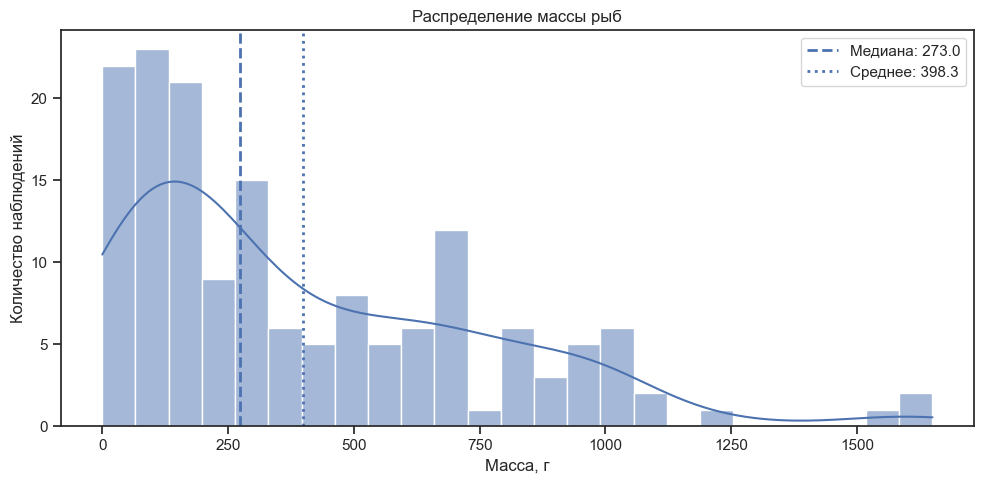

In [25]:
# 1. Распределение Weight с медианой и средним
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df["Weight"], bins=25, kde=True, ax=ax)
ax.axvline(df["Weight"].median(), linestyle="--", linewidth=2, label=f"Медиана: {df['Weight'].median():.1f}")
ax.axvline(df["Weight"].mean(), linestyle=":", linewidth=2, label=f"Среднее: {df['Weight'].mean():.1f}")

ax.set_title("Распределение массы рыб")
ax.set_xlabel("Масса, г")
ax.set_ylabel("Количество наблюдений")
ax.legend()

plt.tight_layout()
plt.savefig("../reports/figures/01_weight_hist_kde.png", dpi=120, bbox_inches="tight")
plt.show()

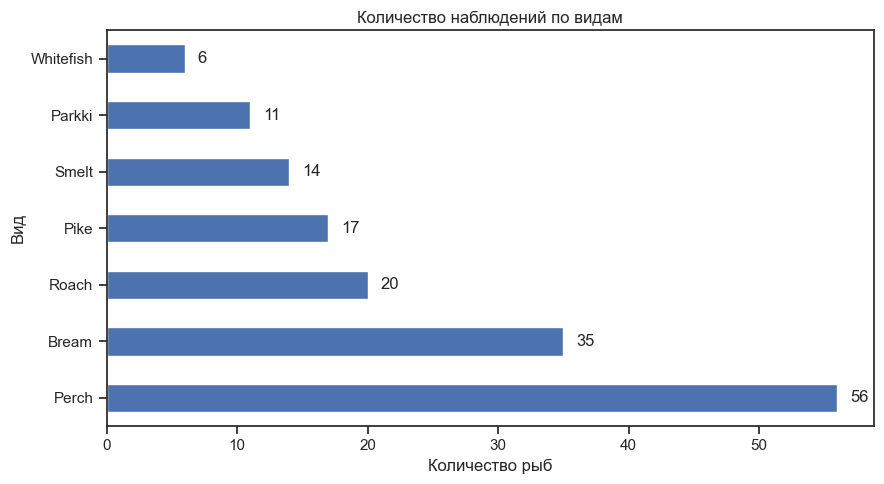

In [26]:
# 2. Доли видов в наборе
species_counts = df["Species"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
species_counts.plot(kind="barh", ax=ax)

ax.set_title("Количество наблюдений по видам")
ax.set_xlabel("Количество рыб")
ax.set_ylabel("Вид")

for i, value in enumerate(species_counts.values):
    ax.text(value + 1, i, str(value), va="center")

plt.tight_layout()
plt.savefig("../reports/figures/02_species_count.png", dpi=120, bbox_inches="tight")
plt.show()

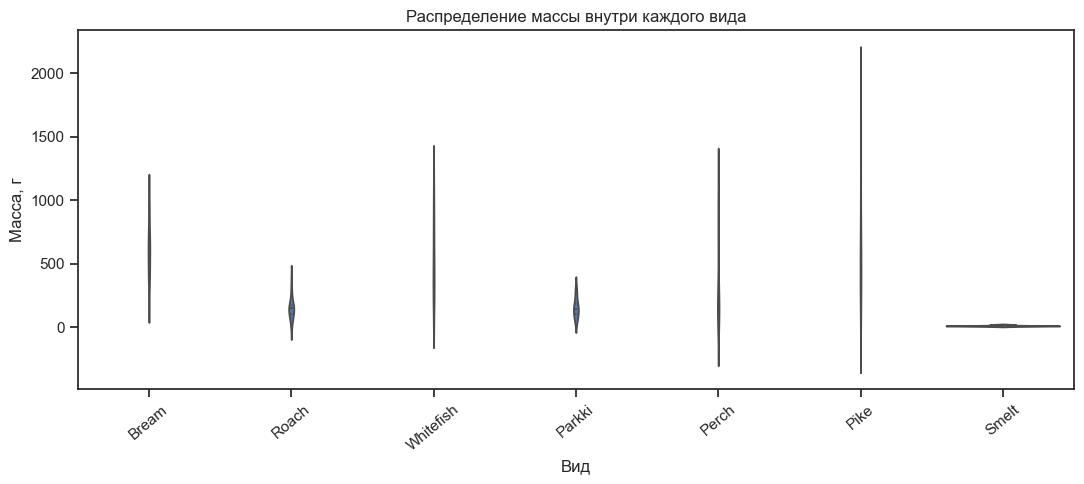

In [27]:
# 3. Сравнение распределений массы по видам
fig, ax = plt.subplots(figsize=(11, 5))

sns.violinplot(
    data=df,
    x="Species",
    y="Weight",
    inner="quartile",
    ax=ax
)

ax.set_title("Распределение массы внутри каждого вида")
ax.set_xlabel("Вид")
ax.set_ylabel("Масса, г")
ax.tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("../reports/figures/03_weight_violin.png", dpi=120, bbox_inches="tight")
plt.show()

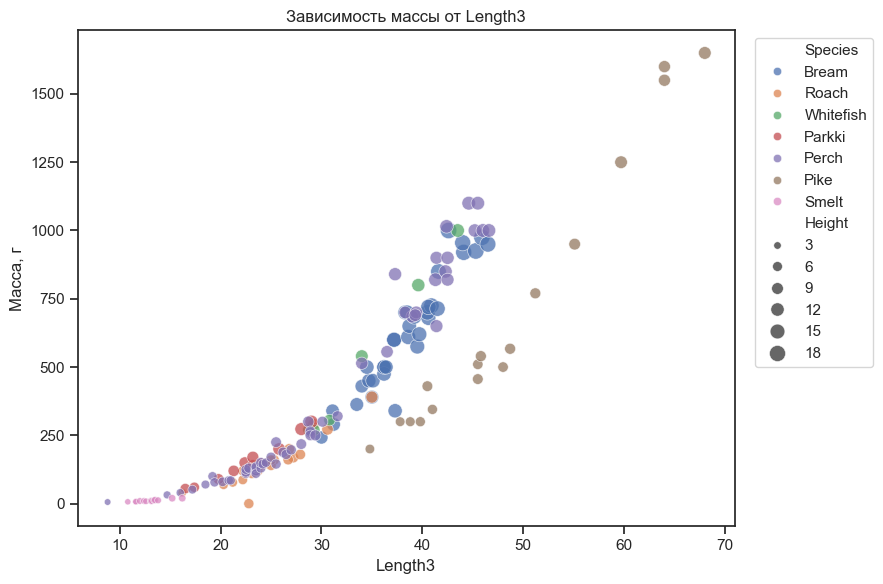

In [28]:
# 4. Связь массы с максимальной длиной
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Length3",
    y="Weight",
    hue="Species",
    size="Height",
    sizes=(20, 140),
    alpha=0.75,
    ax=ax
)

ax.set_title("Зависимость массы от Length3")
ax.set_xlabel("Length3")
ax.set_ylabel("Масса, г")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("../reports/figures/04_weight_length3.png", dpi=120, bbox_inches="tight")
plt.show()

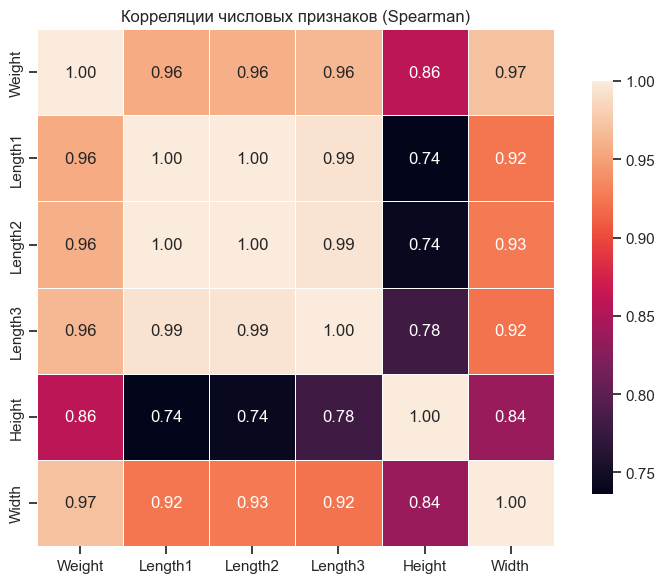

In [29]:
# 5. Корреляционная матрица
corr = df[num_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Корреляции числовых признаков (Spearman)")

plt.tight_layout()
plt.savefig("../reports/figures/05_spearman_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

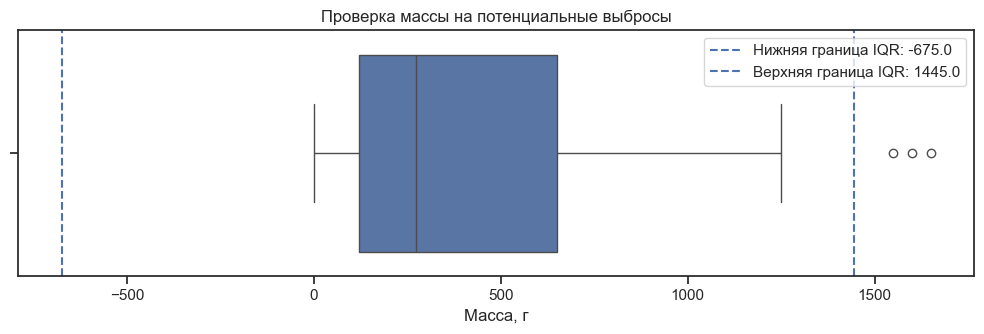

Потенциальных выбросов по правилу 1.5×IQR: 3


In [30]:
# 6. Поиск потенциальных выбросов массы методом IQR
q1 = df["Weight"].quantile(0.25)
q3 = df["Weight"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.boxplot(x=df["Weight"], ax=ax)

ax.axvline(lower, linestyle="--", label=f"Нижняя граница IQR: {lower:.1f}")
ax.axvline(upper, linestyle="--", label=f"Верхняя граница IQR: {upper:.1f}")

ax.set_title("Проверка массы на потенциальные выбросы")
ax.set_xlabel("Масса, г")
ax.legend()

plt.tight_layout()
plt.savefig("../reports/figures/06_weight_outliers.png", dpi=120, bbox_inches="tight")
plt.show()

outliers = df[(df["Weight"] < lower) | (df["Weight"] > upper)]
print(f"Потенциальных выбросов по правилу 1.5×IQR: {len(outliers)}")

## 4. Краткие выводы

- `Weight` имеет заметный разброс, поэтому для моделирования полезно дополнительно изучить форму его распределения.
- Число наблюдений у разных видов различается, поэтому сравнение категорий следует проводить с учётом размера каждой группы.
- Между массой и линейными размерами ожидается выраженная связь; график `Weight`–`Length3` позволяет увидеть её непосредственно.
- Числовые признаки длины, высоты и ширины могут быть взаимосвязаны, что отражается в корреляционной матрице.
- Правило IQR помогает выделить наблюдения, которые требуют дополнительной проверки, но само по себе не доказывает наличие ошибки в данных.
- Отсутствие пропусков и проверка диапазонов значений упрощают подготовку набора к дальнейшему анализу.